In [1]:
from astropy.io import fits
import numpy as np
from matplotlib.colors import LogNorm
from astropy.nddata import Cutout2D
from astropy import units as u
from astropy.stats import sigma_clipped_stats
from astropy.stats import SigmaClip
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm  # For logarithmic scale
from photutils.segmentation import SourceCatalog
from photutils.aperture import CircularAperture  # Import the CircularAperture class
from astropy.visualization import simple_norm
from photutils.background import Background2D, MedianBackground
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils.segmentation import deblend_sources
import pandas as pd
import csv
from astropy.io import ascii
from astropy.convolution import Gaussian2DKernel, convolve
from photutils.segmentation import detect_sources
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table
from astropy.nddata import Cutout2D
import os
import pandas as pd 
from PIL import Image
import re 
import glob
from astropy.nddata.utils import extract_array
from photutils.segmentation import detect_sources, deblend_sources
from photutils.segmentation import SourceCatalog
from astropy.nddata.utils import NoOverlapError
from matplotlib.colors import PowerNorm
from astropy.cosmology import Planck18 as cosmo

In [ ]:
project_input ='1181'
observation_input = '1'
filter_input = '090w'
# # padding = 100
contrast = 0.5

# runs = ['7_0', '9', '10', '12', '13', '15', '16', '18']

# areas = [0.003957476792692257, 3957479430613805, 0.003957468902784528, 0.003957470712196923, 0.003957449357711533, 0.003957436621137778, 0.003957455992335724, 0.003957453798623212]


transients_name = "Transients_AT2024vqf.txt"    #this includes a list of all the SNe informtion along with their type 
# px_area = 0.003957476792692257 #obs_7 F356W
# px_area = 0.003957479430613805 #obs 9
# px_area = 0.003957468902784528 #obs 10
# px_area = 0.003957470712196923 #arcsec^2 per pixel for the F356W filter in obs 12
# px_area = 0.003957449357711533 #obs 13
# px_area = 0.003957436621137778 #obs 15
# px_area = 0.003957455992335724 #obs 16
# px_area = 0.003957453798623212 #obs 18
# px_area = 0.003957288299165857 # for 1210_356W
# px_area = 0.000975191002750790 #for 1210_090W
# px_area = 0.000975145917930543 #for 1210_115W
# px_area = 0.000975143832806780 #for 1210_150W
# px_area = 0.000975232921728961 #for 1210_200w
# px_area = 0.003957333508123717 #for 1210_277w
# px_area = 0.003957887646841713 #for 1210_444w
# px_area = 0.003957207490259441 #3577
# px_area = 0.003957276431426899 #1181-1
# px_area = 0.003957274730098427 #1181-2
# px_area= 0.003957273442983569 #1181-3
# px_area = 0.003957265651505899 # 1181-4
# px_area = 0.003957262234590225 #1181-5
# px_area = 0.003957248898803100 #1181-7
px_area = 0.000975142761109627 #for 1181-1, 115W

In [3]:
os.getcwd()

'g:\\Supernova_project'

In [4]:
# function locates the correct fits image file based on program number, obs no, and filter name 
def project(project_id, obs_no, filter_name): 
    original_dir = os.getcwd() #getting original directory
    os.chdir('Data') #going to the folder where all the data is saved

    # locating the project folder based on the Project ID and JWST obs no  
    project_folder = [d for d in glob.glob("*") if os.path.isdir(d) and project_id in d and obs_no in d]

    if not project_folder:
        raise ValueError(f"No project folder found matching project_id={project_id} and obs_no={obs_no}")
    folder = project_folder[0]
    
    # all files are under the 'JWST' subfolder under the project foler. Entering JWST folder. 
    project_subfolder = os.path.join(folder, 'JWST')
    os.chdir(project_subfolder) #all future outputs will be in here so changing directory again

    # locating the image file based on the filter name     
    image_file = [f for f in glob.glob(f"*{filter_name}*.fits") if os.path.isfile(f)]
    
    if not image_file: 
        raise ValueError(f"No image file found matching filter_name={filter_name}")
    image = os.path.abspath(image_file[0])

    os.chdir(original_dir)

    return image


In [5]:
# this function returns the path of the background subtracted image or creates one and returns the filepath along with the background which will later be used as a threshold for detection
def subtractor(fits_image):

    back_folder = "back" # creating a new output directory for the background subtracted fits files and threshold data
    image_dir = os.path.dirname(fits_image) #extracting image directory
    image_name = os.path.basename(fits_image) #extracting image name  
    back_dir = os.path.join(image_dir, back_folder)  #directory for saving basckground subtracted files
    os.makedirs(back_dir, exist_ok=True)             # Create directory if needed
    back_image = os.path.join(back_dir, image_name) #name of output fits image 

    sigma_clip = SigmaClip(sigma=3) 
    bkg_estimator = MedianBackground() #estimating the background
 
    with fits.open(fits_image) as hdul:
        hdr = hdul[1].header
        image_data = hdul[1].data  # Read data from FITS file. Image data is typically in the second HDU 
        # but when I save the background subtracted image, it will be in the first HDU

    bkg = Background2D(image_data, (100, 100), filter_size=(3, 3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator) #taking the background in a 100x100 pixel square 
 
    th =  1*bkg.background_rms #setting the default threshold as the background_rms. The sources function later tries out different detection thresholds starting with 2*background_rms 
    data_back = image_data - bkg.background #subtracting the backgroound from the image 

    back_header = hdr.copy()
    hdu_back = fits.PrimaryHDU(header=back_header, data=data_back)
    hdul_new = fits.HDUList([hdu_back])
    hdul_new.writeto(back_image, overwrite=True)
    hdul_new.close()

    return (os.path.abspath(back_image), th)

In [6]:
# function that creates cutouts of hosts and transients based on the co-ordinates of the host and transients 

def cutouts(original_image, back_image, filter_name, th):

    # reading in data from background subtracted image 
    with fits.open(back_image) as hdul:
        image_data = hdul[0].data  # Read data from FITS file. In background subtracted images, my data is in the first HDU
        original_header = hdul[0].header
        wcs = WCS(original_header)

    # reading in file with transients data 
    working_directory = os.path.dirname(original_image)
  

    transients_file = os.path.join(working_directory, transients_name)
    df = pd.read_csv(transients_file, header=None, sep=r'\t+')
    df.columns = ['Server_Name', 'Transient_Name', 'RA', 'Dec', 'Host_RA', 'Host_Dec', 'Redshift', 'Type']

     # convert RA/Dec pixel coordinates 
    sky_coords_transient = SkyCoord([SkyCoord(ra, dec, unit=(u.hourangle, u.deg)) if ':' in str(ra) else SkyCoord(float(ra), float(dec), unit=(u.deg, u.deg)) for ra, dec in zip(df['RA'], df['Dec'])])
    tempX_transient, tempY_transient = wcs.world_to_pixel(sky_coords_transient) #converting the sky coordinates to a pixel coordinate system 
    sky_coords_host = SkyCoord([SkyCoord(ra, dec, unit=(u.hourangle, u.deg)) if ':' in str(ra) else SkyCoord(float(ra), float(dec), unit=(u.deg, u.deg)) for ra, dec in zip(df['Host_RA'], df['Host_Dec'])])   
    tempX_host, tempY_host = wcs.world_to_pixel(sky_coords_host) #converting the sky coordinates to a pixel coordinate system 

    cutouts_transients = [] #making a list for transient and host coordinates converted to cutout coordinates 
    cutouts_host = [] 

    output_dir = f'{filter_name}' #this directory will store all the cutouts for a particular filter. It will fall under the main project directory
    host_directory = os.path.join(working_directory, output_dir)
    os.makedirs(host_directory, exist_ok=True) #creating the output directory if it doesn't exist

    # actually starting to create cutouts of transients
    x_transient = []
    y_transient = []
    x_host = []
    y_host = []
    name = []
    z = []
    type = [] #this is already things we have so far, nothing new 
    arcsec =[]
    kpc = []

    for i, (x, y, x_h, y_h) in enumerate(zip(tempX_transient, tempY_transient, tempX_host, tempY_host)):
        
        ny, nx = image_data.shape #a condition that lets us skip to the next transient if the transient is not in this field 
        if not (0 <= x < nx and 0 <= y < ny and 0 <= x_h < nx and 0<= y_h < ny):
            continue 

        x_transient.append(x)
        y_transient.append(y)
        x_host.append(x_h)
        y_host.append(y_h)
        name.append(df.loc[i, 'Transient_Name'])
        z.append(df.loc[i, 'Redshift'])
        type.append(df.loc[i, 'Type'])

        # we look at the center point between the host and the transient to decide the cutout center 
        center_x = (x_transient[-1]+x_host[-1])/2
        center_y = (y_transient[-1]+y_host[-1])/2 
        center = (center_x, center_y)
        distance = np.hypot(x_host[-1]-x_transient[-1], y_host[-1]-y_transient[-1]) #pixel separation between transient and host 
         # to make sure that the entire host galaxy is captured in the image. For LW, the padding should be half i.e 50 since it covers twice the area/pixel
        # cutout_size = int(distance+padding)

        # making a cutout with a fixed size 
        arcsec_pix = np.sqrt(px_area) #getting the arcsec per pixel 

        # for a given z, converting the sky angular separation to physical distance in kpc 
        scale = cosmo.kpc_proper_per_arcmin(df.loc[i, 'Redshift']).to(u.kpc/u.arcsec).value

        fixed_kpc = 10  # desired half-width in kpc
        fixed_arcsec = fixed_kpc / scale          # → arcsec
        fixed_pixels = fixed_arcsec / arcsec_pix  # → pixels

        cutout_size = int(2 * fixed_pixels)  # full side length (50 kpc each side)
        host_cutout = Cutout2D(image_data, center, cutout_size, wcs=wcs)

        offset_arcsec = distance * arcsec_pix
        offset_kpc = scale * offset_arcsec

        arcsec.append(offset_arcsec)
        kpc.append(offset_kpc)

        # host_cutout = Cutout2D(image_data, center, cutout_size, wcs=wcs) # convert x_pix and y_pix into cutout coordinates for plotting 
        cutouts_transients.append(host_cutout.to_cutout_position((x_transient[-1], y_transient[-1])))
        cutouts_host.append(host_cutout.to_cutout_position((x_host[-1], y_host[-1])))
        cutout_rms = extract_array(th, shape=host_cutout.shape, position=host_cutout.input_position_cutout) # creating cutouts also of the threshold values used for background subtraction
        cutout_threshold = cutout_rms #threshold for source detection 
        cutout_file = f"{name[-1]}.txt"
        np.savetxt(os.path.join(host_directory, cutout_file), cutout_threshold, fmt="%.5f")

        # creating path for saving as a fits file   
        filename = f"Transient_{name[-1]}.fits"  # Save to FITS file
        full_path = os.path.join(host_directory, filename)
        # saving as a fits file 
        new_header = original_header.copy()
        new_header.update(host_cutout.wcs.to_header())
        hdu = fits.PrimaryHDU(data=host_cutout.data, header=new_header) # Create a new PrimaryHDU with the cutout data     
        hdul = fits.HDUList([hdu])
        hdul.writeto(full_path, overwrite=True)
        hdul.close() 
        
        # making an image with the axes plotted to confirm astromerty
        # my_norm = PowerNorm(gamma=0.5, vmin=host_cutout.data.min(), vmax=host_cutout.data.max())

        # vmin = np.percentile(image_data, 1)
        # vmax = np.percentile(image_data, 99)
        # my_norm = PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax)
        # my_norm = PowerNorm(gamma=0.5, vmin=image_data.min(), vmax=image_data.max())

        vmin = np.percentile(image_data[image_data > 0], 1)
        vmax = np.percentile(image_data[image_data > 0], 99.9)

        # vmin = image_data[image_data > 0].min()
        # vmax = image_data[image_data > 0].max()
        my_norm = PowerNorm(gamma=0.6, vmin=vmin, vmax=vmax)

        plt.figure(figsize=(4, 4))
        # plt.imshow(host_cutout.data, cmap='hot', origin='lower', vmin=-0.0075, vmax=0.05)
        # plt.imshow(host_cutout.data, cmap='hot', origin='lower', vmin=-0.05, vmax=0.05)

        plt.imshow(host_cutout.data, cmap='hot', origin='lower', norm=my_norm)
        plt.text(0.02, 0.98, fr"{name[-1]}", color='white', fontsize=12, fontweight='medium', ha='left', va='top', transform=plt.gca().transAxes)
        plt.scatter(cutouts_transients[-1][0], cutouts_transients[-1][1], color='green', s=50, marker = '+') #marking the transients 
        plt.scatter(cutouts_host[-1][0], cutouts_host[-1][1], color='green', marker = '.', s=50) #marking the host
        # plt.axis('off')
        png_filename = f"{name[-1]}_{z[-1]}.png"
        plt.savefig(os.path.join(host_directory, png_filename), bbox_inches='tight', pad_inches=0)
        plt.close()

        # making a figure with no axes for the mosaic 
        plt.figure(figsize=(4, 4))
        # plt.imshow(host_cutout.data, cmap='hot', origin='lower', vmin=-0.01, vmax=0.05)
        plt.imshow(host_cutout.data, cmap='hot', origin='lower', norm=my_norm)
        plt.text(0.02, 0.98, fr"{name[-1]}, z={z[-1]}", color='white', fontsize=16, fontweight='bold', ha='left', va='top', transform=plt.gca().transAxes)
        plt.scatter(cutouts_transients[-1][0], cutouts_transients[-1][1], color='green', s=35, marker = '+') #marking the transients 
        plt.scatter(cutouts_host[-1][0], cutouts_host[-1][1], color='green', marker = '.') #marking the host
        plt.axis('off')
        png_filename = f"{name[-1]}_mos.png"
        plt.savefig(os.path.join(host_directory, png_filename), bbox_inches='tight', pad_inches=0)
        plt.close() 

    # creating a new dataframe for the transients in this field 
    field = pd.DataFrame()
    field['Transient_Name'] = name 
    field['X_transient'] = x_transient
    field['Y_transient'] = y_transient
    field['X_host'] = x_host
    field['Y_host'] = y_host
    field['Redshift'] = z 
    field['Type'] = type 
    field['Transient_x_cutout'] = [coord[0] for coord in cutouts_transients]
    field['Transient_y_cutout'] = [coord[1] for coord in cutouts_transients] 
    field['Host_x_cutout'] = [coord[0] for coord in cutouts_host]
    field['Host_y_cutout'] = [coord[1] for coord in cutouts_host]
    field['Offset_arcsec'] = arcsec
    field['Offset_kpc'] = kpc

    # plotting transients on the image 
    plt.figure(figsize=(12, 12))
    plt.imshow(image_data, origin='lower', cmap='gray', vmin=-0.0005, vmax=0.05) 
    plt.scatter(x_transient, y_transient, s=30, edgecolor='red', facecolor='none')
    plt.scatter(x_host, y_host, s=30, edgecolor='g', facecolor='none')

    # Add index labels next to each transient
    for i, (x, y) in enumerate(zip(x_transient, y_transient)):
        plt.text(x + 7, y + 7, str(i+1), color='red', fontsize=8, weight='bold')

    # add index labels to each host
    for i, (x, y) in enumerate(zip(x_host, y_host)):
        plt.text(x + 7, y + 7, str(i+1), color='g', fontsize=8, weight='bold')

    plt.legend()  
    plt.savefig("Transients in field", bbox_inches='tight')
    transients_field = os.path.splitext(os.path.basename(back_image))[0]
    plt.savefig(os.path.join(host_directory, transients_field), bbox_inches='tight')
    plt.show()
    plt.close() 

    return field, os.path.abspath(host_directory)


In [7]:
# function to detect sources from the cutouts 

def sources(df, working_directory):

    transient_cdfs = []
    fluxes = []
    detection_thresholds = []

    for i in range(len(df['Transient_Name'])):
        image_file = os.path.join(working_directory, f"Transient_{df.loc[i, 'Transient_Name']}.fits")
        
        with fits.open(image_file) as hdul:
            image_data = hdul[0].data 
        threshold_data = np.loadtxt(os.path.join(working_directory, f"{df.loc[i, 'Transient_Name']}.txt"))
        
        kernel = Gaussian2DKernel(x_stddev=2)
        convolved_data = convolve(image_data, kernel)

        th_levels = [2.0, 1.0, 0.75, 0.25] #we use the different threshold levels to ensure that 1. the host is detected, and 2. the host and SN are in the same segment 

        seg_map = None
        seg_deblend = None  
        transient_detected = False 
        label = None 
        label_transient = None 

        for th in th_levels:

            segm = detect_sources(convolved_data, th*threshold_data, npixels=3) #given that the host is detected 
            
            if segm is not None and np.mean(segm.data) > 0: 
                deblended = deblend_sources(convolved_data, segm, npixels=3, nlevels=16, contrast=contrast, progress_bar=False)
                l = deblended.data[int(df.loc[i, 'Host_y_cutout']), int(df.loc[i, 'Host_x_cutout'])] #extracting the segment label for the host
                l_transient = deblended.data[int(df.loc[i, 'Transient_y_cutout']), int(df.loc[i, 'Transient_x_cutout'])] #extracting the segment label for the transient
             
                if l == l_transient and l != 0: #the host and SN are in the same segment 
                    seg_map = segm  
                    seg_deblend = deblended
                    label = l
                    label_transient = l_transient
                    detection_thresholds.append(th)
                    transient_detected = True
                    break
                elif l == 0: #if the host is not detected, we try a lower threshold 
                    print(f"No sources found in {df.loc[i, 'Transient_Name']} at {th}")
                    seg_map = segm 
                    seg_deblend = deblended
                    continue
                elif l != l_transient: #if the host and SN are not in the same segment, we try a lower detection threshold. This is usually when the transient is on the outskirts of the host
                    print(f"Transient {df.loc[i, 'Transient_Name']} is not in same segment as host")
                    seg_map = segm 
                    seg_deblend = deblended
                    continue
        
        if not transient_detected: #this is if the SN is not in same segment as host, even for the lowest detection threshold 
            detection_thresholds.append(0)
            transient_cdfs.append(0)
            fluxes.append(0)
            print(f"No sources detected for {df.loc[i, 'Transient_Name']} at any threshold.")

        if transient_detected:
            catalogue = SourceCatalog(convolved_data, seg_deblend) #creating a catalogue of the source properties 

            host_galaxy = catalogue[label-1]
            # print("Flux:", host_galaxy.segment_flux)
            host_tbl = host_galaxy.to_table()

            # extracting pixel values of the source using the segmentation map 
            source_mask = seg_deblend.data == label  # mask for source pixels
            pixel_values = convolved_data[source_mask]  # or image_data[source_mask]

            # creating a cdf 
            sorted_fluxes = np.sort(pixel_values)
            transient_value = convolved_data[int(df.loc[i, 'Transient_y_cutout']), int(df.loc[i, 'Transient_x_cutout'])] #pulling out the flux value at the SNe location
        
            # transient_value = source_mask[int(df.loc[i, 'Transient_y_cutout']), int(df.loc[i, 'Transient_x_cutout'])] #pulling out the flux value at the SNe location

            total = np.sum(sorted_fluxes)
            ratios = sorted_fluxes/total
            f_light = np.cumsum(ratios)

            transient_index=None
            
            for j in range(0, len(sorted_fluxes)):
                if sorted_fluxes[j] == transient_value:
                    transient_index = j

            transient_flight = np.round(f_light[transient_index], 2)
            transient_cdfs.append(transient_flight) #adding the last value of the transient_cdf array to the transient_cdfs list to then store in the dataframe 
            pixel_number = np.linspace(1, len(sorted_fluxes), len(sorted_fluxes))

            # making a plot for the f_light 
            plt.figure(figsize=(5, 3))
            plt.plot(pixel_number, f_light)
            plt.scatter(pixel_number[transient_index], transient_flight, s=30, color='red', marker='x', zorder=10)  
            plt.xlabel('Pixel Number') 
            plt.ylabel(r"$f_{\text{light}}$")
            plt.title(f"{df.loc[i, 'Transient_Name']} CDF") 
            plot_path = os.path.join(working_directory, f"{df.loc[i, 'Transient_Name']}_cdf.png")
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            plt.close()

            # image of segmentation map
            plt.imshow(seg_deblend.data, origin='lower', interpolation='nearest')
            plt.scatter(df.loc[i, 'Transient_x_cutout'], df.loc[i, 'Transient_y_cutout'], edgecolor='r', facecolor='none', s=100)
            plt.scatter(df.loc[i, 'Host_x_cutout'], df.loc[i, 'Host_y_cutout'], edgecolor='g', facecolor='none', s=100)
            plt.title(f"{df.loc[i, 'Transient_Name']}")
            seg_file = os.path.join(working_directory, f"{df.loc[i, 'Transient_Name']}_seg.png")
            plt.savefig(seg_file, dpi=300, bbox_inches='tight')
            plt.close()

    df['Transient_cdf'] = transient_cdfs 
    df['Detection'] = detection_thresholds

    # saving updated dataframe as a text file 
    updated_df = 'Transients_updated.txt'
    df.to_csv(os.path.join(working_directory, updated_df), sep='\t')   
 
    return df

In [8]:
# #if you want to loop through a set of observation runs -- make sure to comment out all the cells below

# transients_2022 = ['9', '12', '13', '16'] #for transients observed in 2022 in GOODS-S, the project should be 1180
# transients_2023 =['7_0', '10', '15','18_0'] #for transients observed in 2023 in GOODS-S, the project should be 1180
# transients_N = ['1','2','3', '4','5', '7'] #for transients observed in 2024 in GOODS-N, the project should be 1181  
# For transients observed in 2023 in GOODS-N, we simply use 3577 and 1_0

# for f in transients_2023:
#     field_image = project("1180", f, '150w')
#     print(field_image)
#     image_subtracted, threshold = subtractor(field_image)
#     print(image_subtracted)
#     transient_info, filter_directory = cutouts(field_image, image_subtracted, '150w', threshold)
#     print(transient_info)
#     print(filter_directory)
#     sources(transient_info, filter_directory)

In [9]:
# runs = ['10', '12', '13', '15', '16', '18']

# areas = [0.003957468902784528, 0.003957470712196923, 0.003957449357711533, 0.003957436621137778, 0.003957455992335724, 0.003957453798623212]


# # filters = ['090w', '115w', '150w', '200w']
# for i in range(8):
#     project_input ='1180'
#     observation_input = runs[i]
#     filter_input = '356w'
#     # padding = 40
#     px_area = areas[i]
#     contrast = 0.5
#     transients_name = "Transients.txt"      #this includes a list of all the SNe informtion along with their type
#     field_image = project(project_input, observation_input, filter_input) 
#     print(field_image)
#     image_subtracted, threshold = subtractor(field_image)
#     print(image_subtracted)
#     transient_info, filter_directory = cutouts(field_image, image_subtracted, filter_input, threshold)
#     print(transient_info)
#     print(filter_directory)
#     sources(transient_info, filter_directory)

In [10]:
# # for a single observation and filter
field_image = project(project_input, observation_input, filter_input)
print(field_image)

g:\Supernova_project\Data\Program1181_18transients_Obs1\JWST\jw01181-o001_t001_nircam_clear-f115w_i2d.fits


In [11]:
# # # # creating background subtracted file 
image_subtracted, threshold = subtractor(field_image)
print(image_subtracted)

g:\Supernova_project\Data\Program1181_18transients_Obs1\JWST\back\jw01181-o001_t001_nircam_clear-f115w_i2d.fits


Set DATE-AVG to '2023-02-03T06:31:40.544' from MJD-AVG.
Set DATE-END to '2023-02-03T07:33:19.399' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    11.853230 from OBSGEO-[XYZ].
Set OBSGEO-H to 1631675297.887 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
C:\Users\Rujuta\AppData\Local\Temp\ipykernel_29916\627169119.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(transients_file, header=None, sep=r'\t+')
C:\Users\Rujuta\AppData\Local\Temp\ipykernel_29916\627169119.py:173: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


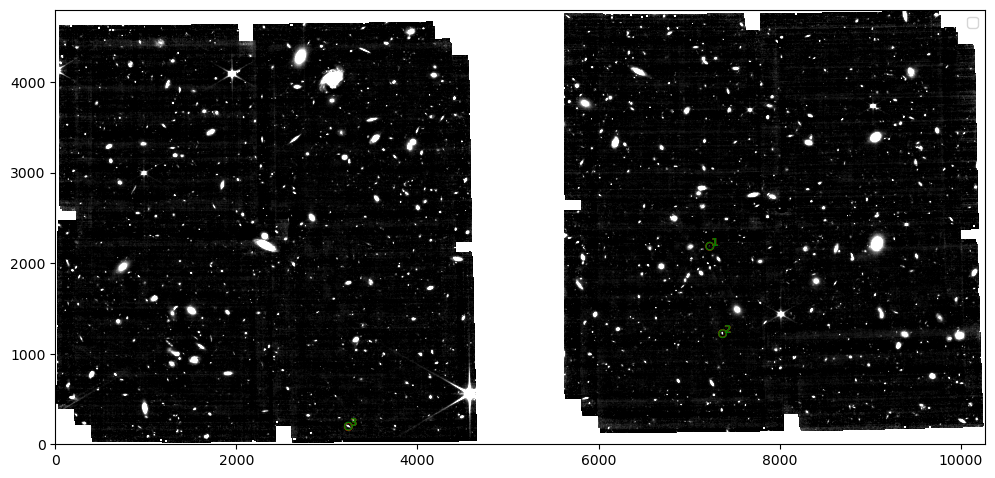

  Transient_Name  X_transient  Y_transient       X_host       Y_host  \
0      AT2024vqb  7227.581049  2185.540242  7228.275356  2186.653302   
1      AT2024vqf  7368.534941  1222.129786  7369.929569  1220.966993   
2      AT2024vqr  3236.607767   195.854326  3237.201573   198.962989   

   Redshift          Type  Transient_x_cutout  Transient_y_cutout  \
0     3.370  Unclassified           41.581049           40.540242   
1     2.426  Unclassified           36.534941           38.129786   
2     0.600  Unclassified           45.607767           44.854326   

   Host_x_cutout  Host_y_cutout  Offset_arcsec  Offset_kpc  
0      42.275356      41.653302       0.040966    0.310976  
1      37.929569      36.966993       0.056702    0.471663  
2      46.201573      47.962989       0.098830    0.680510  
g:\Supernova_project\Data\Program1181_18transients_Obs1\JWST\115w


In [12]:
# # creating cutouts of transients and their hosts 
transient_info, filter_directory = cutouts(field_image, image_subtracted, filter_input, threshold)
print(transient_info)
print(filter_directory)

In [13]:
# detecting sources in cutouts 
sources(transient_info, filter_directory)

,Transient_Name,X_transient,Y_transient,X_host,Y_host,Redshift,Type,Transient_x_cutout,Transient_y_cutout,Host_x_cutout,Host_y_cutout,Offset_arcsec,Offset_kpc,Transient_cdf,Detection
0,AT2024vqb,7227.581049,2185.540242,7228.275356,2186.653302,3.370,Unclassified,41.581049,40.540242,42.275356,41.653302,0.040966,0.310976,0.57,2.0
1,AT2024vqf,7368.534941,1222.129786,7369.929569,1220.966993,2.426,Unclassified,36.534941,38.129786,37.929569,36.966993,0.056702,0.471663,0.83,2.0
2,AT2024vqr,3236.607767,195.854326,3237.201573,198.962989,0.600,Unclassified,45.607767,44.854326,46.201573,47.962989,0.098830,0.680510,0.78,2.0
